In [111]:

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, f1_score, classification_report, make_scorer
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
from datetime import datetime
from pathlib import Path

In [11]:
df = pd.read_csv("Documents/Jarvis/jarvis_data_eng_Li/capstone/data/preprocessed_train.csv")

In [13]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_YEAR,OCCUPATION_TYPE_missing,EXT_SOURCE_3_missing,DAYS_EMPLOYED_missing,AMT_REQ_CREDIT_BUREAU_DAY_missing,AMT_REQ_CREDIT_BUREAU_WEEK_missing,AMT_REQ_CREDIT_BUREAU_MON_missing,AMT_REQ_CREDIT_BUREAU_QRT_missing,AMT_REQ_CREDIT_BUREAU_HOUR_missing,AMT_REQ_CREDIT_BUREAU_YEAR_missing
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1.0,0,0,0,0,0,0,0,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0,1,0,0,0,0,0,0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0,0,0,0,0,0,0,0,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,1.0,0,1,0,1,1,1,1,1,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,1.0,0,1,0,1,1,1,1,1,1
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,1.0,1,1,1,1,1,1,1,1,1
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,1.0,0,0,0,0,0,0,0,0,0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0,0,0,0,0,0,0,0,0


In [15]:
df.shape

(307511, 114)

In [35]:
features = [c for c in df.columns if c != 'TARGET']
X = df[features]
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate - Train: {y_train.mean():.4f}, Test: {y_test.mean():.4f}")

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"Categorical examples: {categorical_cols[:5] if categorical_cols else 'None'}")

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

Train: (246008, 113), Test: (61503, 113)
Default rate - Train: 0.0807, Test: 0.0807

Numeric columns: 98
Categorical columns: 15
Categorical examples: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE']


In [25]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=0.1, max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

auroc_lr = roc_auc_score(y_test, y_proba_lr)
gini_lr = 2 * auroc_lr - 1
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
ks_lr = max(tpr_lr - fpr_lr)
auprc_lr = average_precision_score(y_test, y_proba_lr)

print("LOGISTIC REGRESSION")
print(f'AUROC: {auroc_lr:.4f}')
print(f'Gini:  {gini_lr:.4f}')
print(f'KS:    {ks_lr:.4f}')
print(f'AUPRC: {auprc_lr:.4f}')


LOGISTIC REGRESSION
AUROC: 0.7495
Gini:  0.4990
KS:    0.3691
AUPRC: 0.2312


In [37]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, max_depth=10, 
                                          class_weight='balanced', random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

auroc_rf = roc_auc_score(y_test, y_proba_rf)
gini_rf = 2 * auroc_rf - 1
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
ks_rf = max(tpr_rf - fpr_rf)
auprc_rf = average_precision_score(y_test, y_proba_rf)

print("RANDOM FOREST")
print(f'AUROC: {auroc_rf:.4f}')
print(f'Gini:  {gini_rf:.4f}')
print(f'KS:    {ks_rf:.4f}')
print(f'AUPRC: {auprc_rf:.4f}')



RANDOM FOREST
AUROC: 0.7307
Gini:  0.4615
KS:    0.3429
AUPRC: 0.2093


In [97]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    ))
])

xgb_model.fit(X_train_processed, y_train)
y_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

auroc_xgb = roc_auc_score(y_test, y_proba_xgb)
gini_xgb = 2 * auroc_xgb - 1
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
ks_xgb = max(tpr_xgb - fpr_xgb)
auprc_xgb = average_precision_score(y_test, y_proba_xgb)

print("XGBOOST")
print(f'AUROC: {auroc_xgb:.4f}')
print(f'Gini:  {gini_xgb:.4f}')
print(f'KS:    {ks_xgb:.4f}')
print(f'AUPRC: {auprc_xgb:.4f}')

XGBOOST
AUROC: 0.7576
Gini:  0.5153
KS:    0.3824
AUPRC: 0.2466


In [93]:
print("MODEL COMPARISON")
print(f"{'Model':<20} {'AUROC':<8} {'Gini':<8} {'KS':<8} {'AUPRC':<8}")
print(f"{'Logistic Regression':<20} {auroc_lr:.4f}   {gini_lr:.4f}   {ks_lr:.4f}   {auprc_lr:.4f}")
print(f"{'Random Forest':<20} {auroc_rf:.4f}   {gini_rf:.4f}   {ks_rf:.4f}   {auprc_rf:.4f}")
print(f"{'XGBoost':<20} {auroc_xgb:.4f}   {gini_xgb:.4f}   {ks_xgb:.4f}   {auprc_xgb:.4f}")

best_auroc = max(auroc_lr, auroc_rf, auroc_xgb)
best_auprc = max(auprc_lr, auprc_rf, auprc_xgb)

print(f"\nBest AUROC: {'XGBoost'} - {best_auroc:.4f}")
print(f"Best AUPRC: {'XGBoost'} - {best_auprc:.4f}")

MODEL COMPARISON
Model                AUROC    Gini     KS       AUPRC   
Logistic Regression  0.7495   0.4990   0.3691   0.2312
Random Forest        0.7307   0.4615   0.3429   0.2093
XGBoost              0.7576   0.5153   0.3824   0.2466

Best AUROC: XGBoost - 0.7576
Best AUPRC: XGBoost - 0.2466


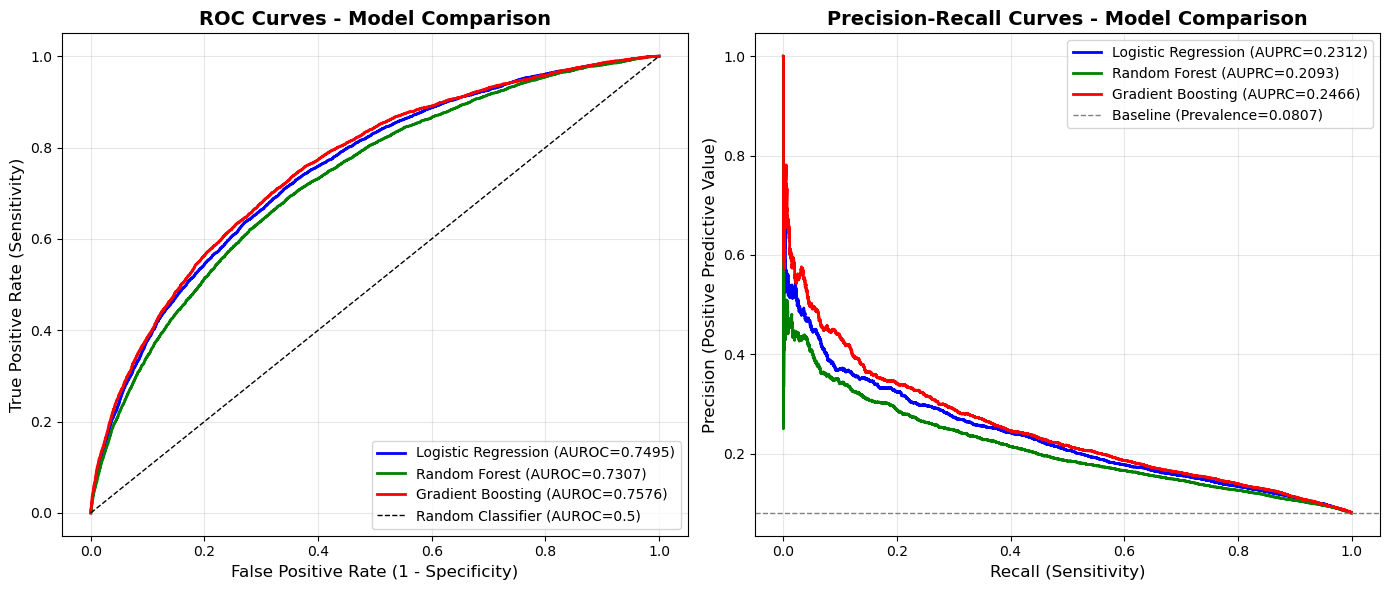

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
axes[0].plot(fpr_lr, tpr_lr, 'b-', lw=2, label=f'Logistic Regression (AUROC={auroc_lr:.4f})')
axes[0].plot(fpr_rf, tpr_rf, 'g-', lw=2, label=f'Random Forest (AUROC={auroc_rf:.4f})')
axes[0].plot(fpr_xgb, tpr_xgb, 'r-', lw=2, label=f'Gradient Boosting (AUROC={auroc_xgb:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUROC=0.5)')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Precision-Recall curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_proba_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)

axes[1].plot(recall_lr, precision_lr, 'b-', lw=2, label=f'Logistic Regression (AUPRC={auprc_lr:.4f})')
axes[1].plot(recall_rf, precision_rf, 'g-', lw=2, label=f'Random Forest (AUPRC={auprc_rf:.4f})')
axes[1].plot(recall_xgb, precision_xgb, 'r-', lw=2, label=f'Gradient Boosting (AUPRC={auprc_xgb:.4f})')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1, label=f'Baseline (Prevalence={y_test.mean():.4f})')
axes[1].set_xlabel('Recall (Sensitivity)', fontsize=12)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[1].set_title('Precision-Recall Curves - Model Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Documents/Jarvis/jarvis_data_eng_Li/capstone/models/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [95]:
print("\n" + "="*80)
print("TASK 8: CROSS-VALIDATION (5-FOLD STRATIFIED)")
print("="*80)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# Perform cross-validation (use 'roc_auc' directly - it works!)
print("\nLogistic Regression CV:")
lr_cv_scores = cross_val_score(lr_pipeline, X, y, cv=cv, scoring='roc_auc')
print(f"   Scores: {[f'{s:.4f}' for s in lr_cv_scores]}")
print(f"   Mean AUROC: {lr_cv_scores.mean():.4f} (±{lr_cv_scores.std():.4f})")

print("\nRandom Forest CV:")
rf_cv_scores = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='roc_auc')
print(f"   Scores: {[f'{s:.4f}' for s in rf_cv_scores]}")
print(f"   Mean AUROC: {rf_cv_scores.mean():.4f} (±{rf_cv_scores.std():.4f})")

print("\nGradient Boosting CV:")
gb_cv_scores = cross_val_score(xgb_pipeline, X, y, cv=cv, scoring='roc_auc')
print(f"   Scores: {[f'{s:.4f}' for s in gb_cv_scores]}")
print(f"   Mean AUROC: {gb_cv_scores.mean():.4f} (±{gb_cv_scores.std():.4f})")


print("CROSS-VALIDATION SUMMARY (5-fold Stratified)")
print(f"{'Model':<20} {'Mean AUROC':<12} {'Std AUROC':<12}")
print(f"{'Logistic Regression':<20} {lr_cv_scores.mean():.4f}        ±{lr_cv_scores.std():.4f}")
print(f"{'Random Forest':<20} {rf_cv_scores.mean():.4f}        ±{rf_cv_scores.std():.4f}")
print(f"{'Gradient Boosting':<20} {gb_cv_scores.mean():.4f}        ±{gb_cv_scores.std():.4f}")

# Best model by CV
cv_means = {'Logistic Regression': lr_cv_scores.mean(), 
            'Random Forest': rf_cv_scores.mean(), 
            'Gradient Boosting': gb_cv_scores.mean()}
best_cv_model = max(cv_means, key=cv_means.get)
print(f"\nBest model by CV AUROC: {best_cv_model} ({cv_means[best_cv_model]:.4f})")


TASK 8: CROSS-VALIDATION (5-FOLD STRATIFIED)

📊 Logistic Regression CV:
   Scores: ['0.7435', '0.7532', '0.7483', '0.7521', '0.7414']
   Mean AUROC: 0.7477 (±0.0046)

📊 Random Forest CV:
   Scores: ['0.7248', '0.7307', '0.7213', '0.7343', '0.7267']
   Mean AUROC: 0.7276 (±0.0045)

📊 Gradient Boosting CV:
   Scores: ['0.7553', '0.7637', '0.7567', '0.7629', '0.7528']
   Mean AUROC: 0.7583 (±0.0043)

CROSS-VALIDATION SUMMARY (5-fold Stratified)
Model                Mean AUROC   Std AUROC   
------------------------------------------------------------
Logistic Regression  0.7477        ±0.0046
Random Forest        0.7276        ±0.0045
Gradient Boosting    0.7583        ±0.0043

🏆 Best model by CV AUROC: Gradient Boosting (0.7583)


In [103]:
X_processed = preprocessor.fit_transform(X)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

if best_cv_model == 'XGB':
    param_dist = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'min_samples_split': [2, 5, 10]
    }
    base_model = XGBClassifier(random_state=42)
elif best_cv_model == 'Random Forest':
    param_dist = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    base_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
else:
    param_dist = {
        'C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga']
    }
    base_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

random_search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_processed, y_train)

print(f"\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\nBest CV AUROC: {random_search.best_score_:.4f}")

# Evaluate on test set
best_model_tuned = random_search.best_estimator_
y_proba_best = best_model_tuned.predict_proba(X_test_processed)[:, 1]
test_auroc = roc_auc_score(y_test, y_proba_best)
test_auprc = average_precision_score(y_test, y_proba_best)

print(f"\nTest set performance:")
print(f"   AUROC: {test_auroc:.4f}")
print(f"   AUPRC: {test_auprc:.4f}")

Tuning Gradient Boosting...

Parameter grid size: 576 combinations
Running RandomizedSearchCV with 50 iterations...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


C:\Users\Jason Li\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:57:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ Search complete!

🏆 Best parameters found:
   subsample: 0.6
   n_estimators: 500
   min_samples_split: 2
   max_depth: 3
   learning_rate: 0.05

Best CV AUROC: 0.7563

📊 Test set performance:
   AUROC: 0.7610
   AUPRC: 0.2523


In [115]:
best_full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model_tuned)
])

model_path = Path('Documents/Jarvis/jarvis_data_eng_Li/capstone/models/best_model.pkl')
joblib.dump(best_full_pipeline, model_path)

metadata_path = Path('Documents/Jarvis/jarvis_data_eng_Li/capstone/models/model_metadata.json')
metadata = {
    'model_type': best_model_name,
    'best_params': random_search.best_params_,
    'test_auroc': test_auroc,
    'test_auprc': test_auprc,
    'saved_date': datetime.now().strftime("%Y-%m-%d")
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
